In [1]:
import yfinance as yf
from datetime import datetime, timedelta

# First, let's define the tickers for Nifty 50 and Reliance, and calculate the start and end dates for the past 10 years.

In [ ]:
nifty_ticker = '^NSEI'  # Nifty 50 index ticker
reliance_ticker = 'RELIANCE.NS' # Reliance Industries ticker on NSE

end_date = datetime.now()
start_date = end_date - timedelta(days=10*365) # Approximately 10 years

Now, let's download the historical data for Nifty 50 and display the first few rows.

In [ ]:
nifty_data = yf.download(nifty_ticker, start=start_date, end=end_date)
display(nifty_data.head())

/tmp/ipykernel_774/3238071422.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(nifty_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2016-08-01,8636.549805,8711.299805,8590.500000,8654.299805,188400
2016-08-02,8622.900391,8687.200195,8611.400391,8647.450195,169400
2016-08-03,8544.849609,8635.450195,8529.599609,8635.200195,163000
2016-08-04,8551.099609,8601.400391,8518.150391,8599.950195,164700
2016-08-05,8683.150391,8689.400391,8590.150391,8600.200195,157900


Next, we will download the historical data for Reliance stock and display its first few rows.

In [ ]:
reliance_data = yf.download(reliance_ticker, start=start_date, end=end_date)
display(reliance_data.head())

/tmp/ipykernel_774/1905781009.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance_data = yf.download(reliance_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2016-08-01,220.187225,222.542874,219.216612,222.041209,7978251
2016-08-02,220.906998,222.477425,219.489246,219.860046,7710138
2016-08-03,216.795547,221.255991,216.261166,221.255991,11872282
2016-08-04,216.588303,218.115109,214.494399,217.897000,10187608
2016-08-05,221.659470,222.259284,217.471663,217.678866,12109001


In [ ]:
reliance_data.to_csv('reliance_data.csv')
nifty_data.to_csv('nifty_data.csv')


# Task
The user wants to perform a comprehensive stock market analysis and forecasting task for Nifty 50 and Reliance Industries using multiple modeling techniques. The task involves preparing data, engineering features, building various models (ARIMA, GARCH, LSTM/Transformer), comparing their performance, interpreting results with SHAP, and visualizing the findings. The goal is to predict stock prices and volatility, and gain insights into their behavior.

## Prepare Data for Nifty 50

### Subtask:
Prepare the 'nifty_data' for modeling, including selecting relevant columns (e.g., 'Close'), handling missing values, and ensuring the data is in the correct format for time series analysis. This step will also involve creating a date index.


**Reasoning**:
I need to select the 'Close' column, handle missing values, confirm the datetime index, rename the column, and display the head and info of the prepared Nifty 50 data as per the instructions.



In [ ]:
import pandas as pd

nifty_data_cleaned = nifty_data['Close'].copy()
nifty_data_cleaned.ffill(inplace=True) # Using ffill() directly as recommended
nifty_data_cleaned.name = 'Nifty_Close' # Correctly renaming the Series

# Ensure the index is a datetime index (it already is from yfinance.download)
if not isinstance(nifty_data_cleaned.index, pd.DatetimeIndex):
    nifty_data_cleaned.index = pd.to_datetime(nifty_data_cleaned.index)

print("Prepared Nifty 50 Data Head:")
display(nifty_data_cleaned.head())
print("\nPrepared Nifty 50 Data Info:")
nifty_data_cleaned.info()

Prepared Nifty 50 Data Head:


Ticker,^NSEI
Date,
2016-08-01,8636.549805
2016-08-02,8622.900391
2016-08-03,8544.849609
2016-08-04,8551.099609
2016-08-05,8683.150391



Prepared Nifty 50 Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2462 entries, 2016-08-01 to 2026-07-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^NSEI   2462 non-null   float64
dtypes: float64(1)
memory usage: 38.5 KB


## Prepare Data for Reliance

### Subtask:
Prepare the 'reliance_data' for modeling, including selecting relevant columns (e.g., 'Close'), handling missing values, and ensuring the data is in the correct format for time series analysis. This step will also involve creating a date index.


**Reasoning**:
I need to perform the data preparation steps for the Reliance data as outlined in the instructions: select the 'Close' column, handle missing values, rename the series, and verify the datetime index. Finally, display the head and info of the cleaned data.



In [ ]:
reliance_data_cleaned = reliance_data['Close'].copy()
reliance_data_cleaned.ffill(inplace=True)
reliance_data_cleaned.name = 'Reliance_Close'

# Ensure the index is a datetime index (it already is from yfinance.download)
if not isinstance(reliance_data_cleaned.index, pd.DatetimeIndex):
    reliance_data_cleaned.index = pd.to_datetime(reliance_data_cleaned.index)

print("Prepared Reliance Data Head:")
display(reliance_data_cleaned.head())
print("\nPrepared Reliance Data Info:")
reliance_data_cleaned.info()

Prepared Reliance Data Head:


Ticker,RELIANCE.NS
Date,
2016-08-01,220.187225
2016-08-02,220.906998
2016-08-03,216.795547
2016-08-04,216.588303
2016-08-05,221.659470



Prepared Reliance Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2471 entries, 2016-08-01 to 2026-07-29
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RELIANCE.NS  2471 non-null   float64
dtypes: float64(1)
memory usage: 38.6 KB


## Feature Engineering

### Subtask:
Perform feature engineering on both Nifty 50 and Reliance datasets. This includes creating lagged features, moving averages, rolling standard deviations (for volatility), and other relevant technical indicators that could aid in forecasting. These features will be used for both baseline and advanced models.


**Reasoning**:
I need to implement the feature engineering steps for `nifty_data_cleaned` as described in the instructions. This involves creating lagged features, moving averages, rolling standard deviations, and daily returns. After generating these features, I will combine them with the original 'Close' price into a new DataFrame, handle missing values, and then display the head and info of the resulting `nifty_features_df`.



In [ ]:
nifty_features_df = pd.DataFrame(nifty_data_cleaned)
nifty_features_df.columns = ['Nifty_Close']

# Lagged features
for lag in [1, 5, 10, 20]:
    nifty_features_df[f'Nifty_Close_Lag_{lag}'] = nifty_features_df['Nifty_Close'].shift(lag)

# Moving Averages
for window in [5, 10, 20]:
    nifty_features_df[f'Nifty_SMA_{window}'] = nifty_features_df['Nifty_Close'].rolling(window=window).mean()

# Rolling Standard Deviation (Volatility)
for window in [5, 10, 20]:
    nifty_features_df[f'Nifty_Volatility_{window}'] = nifty_features_df['Nifty_Close'].rolling(window=window).std()

# Daily Returns
nifty_features_df['Nifty_Daily_Returns'] = nifty_features_df['Nifty_Close'].pct_change()

# Handle NaN values created by lagging and rolling calculations
nifty_features_df.dropna(inplace=True)

print("Nifty 50 Features DataFrame Head:")
display(nifty_features_df.head())
print("\nNifty 50 Features DataFrame Info:")
nifty_features_df.info()

Nifty 50 Features DataFrame Head:


,Nifty_Close,Nifty_Close_Lag_1,Nifty_Close_Lag_5,Nifty_Close_Lag_10,Nifty_Close_Lag_20,Nifty_SMA_5,Nifty_SMA_10,Nifty_SMA_20,Nifty_Volatility_5,Nifty_Volatility_10,Nifty_Volatility_20,Nifty_Daily_Returns
Date,,,,,,,,,,,,
2016-08-31,8786.200195,8744.349609,8650.299805,8624.049805,8636.549805,8660.550000,8655.495020,8639.029980,97.526491,66.553221,62.680387,0.004786
2016-09-01,8774.650391,8786.200195,8592.200195,8673.250000,8622.900391,8697.040039,8665.635059,8646.617480,99.668518,76.535061,69.444835,-0.001315
2016-09-02,8809.650391,8774.650391,8572.549805,8666.900391,8544.849609,8744.460156,8679.910059,8659.857520,80.117397,89.081485,74.107381,0.003989
2016-09-06,8943.000000,8809.650391,8607.450195,8629.150391,8551.099609,8811.570117,8711.295020,8679.452539,77.140773,119.354381,93.191444,0.015137
2016-09-07,8917.950195,8943.000000,8744.349609,8632.599609,8683.150391,8846.290234,8739.830078,8691.192529,78.379664,131.900684,107.389887,-0.002801



Nifty 50 Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2442 entries, 2016-08-31 to 2026-07-29
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Nifty_Close          2442 non-null   float64
 1   Nifty_Close_Lag_1    2442 non-null   float64
 2   Nifty_Close_Lag_5    2442 non-null   float64
 3   Nifty_Close_Lag_10   2442 non-null   float64
 4   Nifty_Close_Lag_20   2442 non-null   float64
 5   Nifty_SMA_5          2442 non-null   float64
 6   Nifty_SMA_10         2442 non-null   float64
 7   Nifty_SMA_20         2442 non-null   float64
 8   Nifty_Volatility_5   2442 non-null   float64
 9   Nifty_Volatility_10  2442 non-null   float64
 10  Nifty_Volatility_20  2442 non-null   float64
 11  Nifty_Daily_Returns  2442 non-null   float64
dtypes: float64(12)
memory usage: 248.0 KB


In [ ]:
reliance_features_df = pd.DataFrame(reliance_data_cleaned)
reliance_features_df.columns = ['Reliance_Close']

# Lagged features
for lag in [1, 5, 10, 20]:
    reliance_features_df[f'Reliance_Close_Lag_{lag}'] = reliance_features_df['Reliance_Close'].shift(lag)

# Moving Averages
for window in [5, 10, 20]:
    reliance_features_df[f'Reliance_SMA_{window}'] = reliance_features_df['Reliance_Close'].rolling(window=window).mean()

# Rolling Standard Deviation (Volatility)
for window in [5, 10, 20]:
    reliance_features_df[f'Reliance_Volatility_{window}'] = reliance_features_df['Reliance_Close'].rolling(window=window).std()

# Daily Returns
reliance_features_df['Reliance_Daily_Returns'] = reliance_features_df['Reliance_Close'].pct_change()

# Handle NaN values created by lagging and rolling calculations
reliance_features_df.dropna(inplace=True)

print("Reliance Features DataFrame Head:")
display(reliance_features_df.head())
print("\nReliance Features DataFrame Info:")
reliance_features_df.info()

Reliance Features DataFrame Head:


,Reliance_Close,Reliance_Close_Lag_1,Reliance_Close_Lag_5,Reliance_Close_Lag_10,Reliance_Close_Lag_20,Reliance_SMA_5,Reliance_SMA_10,Reliance_SMA_20,Reliance_Volatility_5,Reliance_Volatility_10,Reliance_Volatility_20,Reliance_Daily_Returns
Date,,,,,,,,,,,,
2016-08-30,232.597946,230.645844,220.394440,223.546204,220.187225,226.183197,223.644341,222.563577,5.147826,4.372896,3.924142,0.008464
2016-08-31,231.202011,232.597946,222.586472,221.016037,220.906998,227.906305,224.662938,223.078328,5.084462,4.852662,4.347763,-0.006001
2016-09-01,224.484085,231.202011,220.885193,222.052094,216.795547,228.626083,224.906137,223.462755,3.975934,4.767471,4.095601,-0.029057
2016-09-02,221.027008,224.484085,224.200531,221.365051,216.588303,227.991379,224.872333,223.684690,4.984435,4.796480,3.814064,-0.015400
2016-09-06,222.455612,221.027008,230.645844,220.699799,221.659470,226.353333,225.047914,223.724497,5.233568,4.656873,3.795926,0.006463



Reliance Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2451 entries, 2016-08-30 to 2026-07-29
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Reliance_Close          2451 non-null   float64
 1   Reliance_Close_Lag_1    2451 non-null   float64
 2   Reliance_Close_Lag_5    2451 non-null   float64
 3   Reliance_Close_Lag_10   2451 non-null   float64
 4   Reliance_Close_Lag_20   2451 non-null   float64
 5   Reliance_SMA_5          2451 non-null   float64
 6   Reliance_SMA_10         2451 non-null   float64
 7   Reliance_SMA_20         2451 non-null   float64
 8   Reliance_Volatility_5   2451 non-null   float64
 9   Reliance_Volatility_10  2451 non-null   float64
 10  Reliance_Volatility_20  2451 non-null   float64
 11  Reliance_Daily_Returns  2451 non-null   float64
dtypes: float64(12)
memory usage: 248.9 KB


## ARIMA Baseline Model

### Subtask:
Build and train an ARIMA (AutoRegressive Integrated Moving Average) baseline model for both Nifty 50 and Reliance stock prices. This involves identifying appropriate ARIMA orders (p, d, q) and then fitting the model to the historical data. This step will also include making predictions and evaluating them.


**Reasoning**:
Importing necessary libraries as per the first instruction of the subtask.



In [ ]:
import sys
!{sys.executable} -m pip install pmdarima

import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully: pmdarima, sklearn.metrics, matplotlib.pyplot, numpy")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00
Libraries imported successfully: pmdarima, sklearn.metrics, matplotlib.pyplot, numpy


**Reasoning**:
Defining a function to automate the ARIMA modeling process, including splitting data, finding optimal parameters, training, predicting, evaluating, and visualizing results for a given time series dataset.




Fitting ARIMA model for Nifty 50...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=25033.479, Time=6.01 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=25034.274, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=25033.373, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25033.517, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=25039.180, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=25034.290, Time=0.24 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=25035.191, Time=1.65 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=25038.805, Time=0.08 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 8.606 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1969
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -12513.686
Date:                Wed, 29 Jul 2026   AIC                          2

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


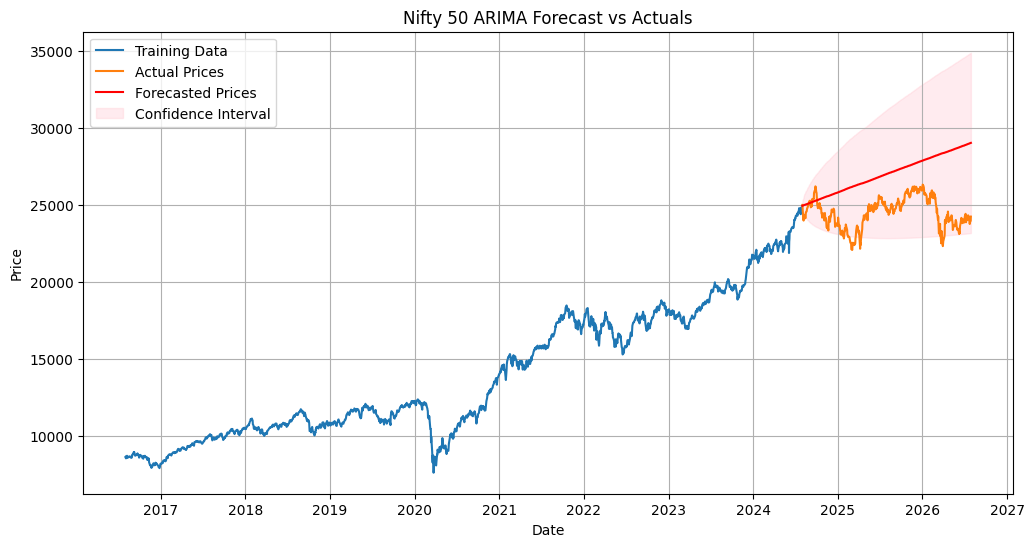

In [ ]:
def arima_model_pipeline(data_series, title_prefix):
    # Ensure data_series is a pandas Series
    if isinstance(data_series, pd.DataFrame):
        if len(data_series.columns) > 1:
            raise ValueError("Input data_series DataFrame has multiple columns. Expected a single column or a Series.")
        data_series = data_series.iloc[:, 0] # Convert single-column DataFrame to Series
    elif not isinstance(data_series, pd.Series):
        raise TypeError("Input data_series must be a pandas Series or a single-column DataFrame.")

    # 1. Split the data into training and testing sets
    train_size = int(len(data_series) * 0.8)
    train_data, test_data = data_series[0:train_size], data_series[train_size:]

    # 2. Identify appropriate ARIMA orders (p, d, q) using auto_arima
    print(f"\nFitting ARIMA model for {title_prefix}...")
    arima_model = pm.auto_arima(train_data,
                                start_p=1, start_q=1,
                                test='adf',       # use adftest to find optimal 'd'
                                max_p=5, max_q=5,  # maximum p and q
                                m=1,              # frequency of series
                                d=None,           # let model determine 'd'
                                seasonal=False,   # No Seasonality
                                start_P=0,
                                D=0,
                                trace=True,
                                error_action='ignore',
                                suppress_warnings=True,
                                stepwise=True)

    print(arima_model.summary())

    # 3. Make predictions
    raw_forecast, raw_conf_int = arima_model.predict(n_periods=len(test_data), return_conf_int=True)

    # If raw_forecast is a pandas Series or DataFrame, extract its values
    if isinstance(raw_forecast, (pd.Series, pd.DataFrame)):
        forecast_values = raw_forecast.values
    else: # Assume it's already a numpy array
        forecast_values = raw_forecast

    if isinstance(raw_conf_int, (pd.Series, pd.DataFrame)):
        conf_int_values = raw_conf_int.values
    else: # Assume it's already a numpy array
        conf_int_values = raw_conf_int

    print(f"Length of forecast_values: {len(forecast_values)}")
    print(f"First 5 values of forecast_values: {forecast_values[:5]}")
    print(f"Length of test_data Series: {len(test_data)}")
    print(f"First 5 indices of test_data: {test_data.index[:5]}")

    # Convert forecast_values and conf_int_values to pandas Series/DataFrame with test_data index
    # This should now correctly map the values if lengths match.
    forecast_series = pd.Series(forecast_values, index=test_data.index)
    conf_int_df = pd.DataFrame(conf_int_values, index=test_data.index, columns=['lower', 'upper'])

    # Debugging: Check for NaNs before evaluation
    print(f"NaNs in test_data before evaluation: {test_data.isnull().sum()}")
    print(f"NaNs in forecast_series before evaluation: {forecast_series.isnull().sum()}")

    # Align actual and forecasted values and drop any NaNs for robust evaluation
    comparison_df = pd.DataFrame({'Actual': test_data, 'Forecast': forecast_series}).dropna()

    if comparison_df.empty:
        print("Warning: No common non-NaN values for evaluation. Skipping RMSE/MAE calculation.")
        rmse = np.nan
        mae = np.nan
    else:
        # 4. Evaluate the predictions
        rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['Forecast']))
        mae = mean_absolute_error(comparison_df['Actual'], comparison_df['Forecast'])

    print(f"\n{title_prefix} ARIMA Model Performance:")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")

    # 5. Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(train_data.index, train_data, label='Training Data')
    plt.plot(test_data.index, test_data, label='Actual Prices')
    plt.plot(forecast_series.index, forecast_series, label='Forecasted Prices', color='red')
    plt.fill_between(conf_int_df.index,
                     conf_int_df['lower'],
                     conf_int_df['upper'],
                     color='pink', alpha=0.3, label='Confidence Interval')
    plt.title(f'{title_prefix} ARIMA Forecast vs Actuals')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    return arima_model, rmse, mae, forecast_series

nifty_arima_model, nifty_arima_rmse, nifty_arima_mae, nifty_arima_forecast = arima_model_pipeline(nifty_data_cleaned, 'Nifty 50')

**Reasoning**:
Calling the `arima_model_pipeline` function for Reliance data to perform ARIMA modeling, evaluation, and visualization.




Fitting ARIMA model for Reliance...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=16121.571, Time=3.16 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=32402.721, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=1.80 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=1.29 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=16120.780, Time=1.94 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=1.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=16123.322, Time=2.39 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=16123.409, Time=2.50 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=16122.179, Time=1.32 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=4.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=3.79 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=16121.403, Time=2.91 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 26.477 seconds
                               SARIMAX Results                      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


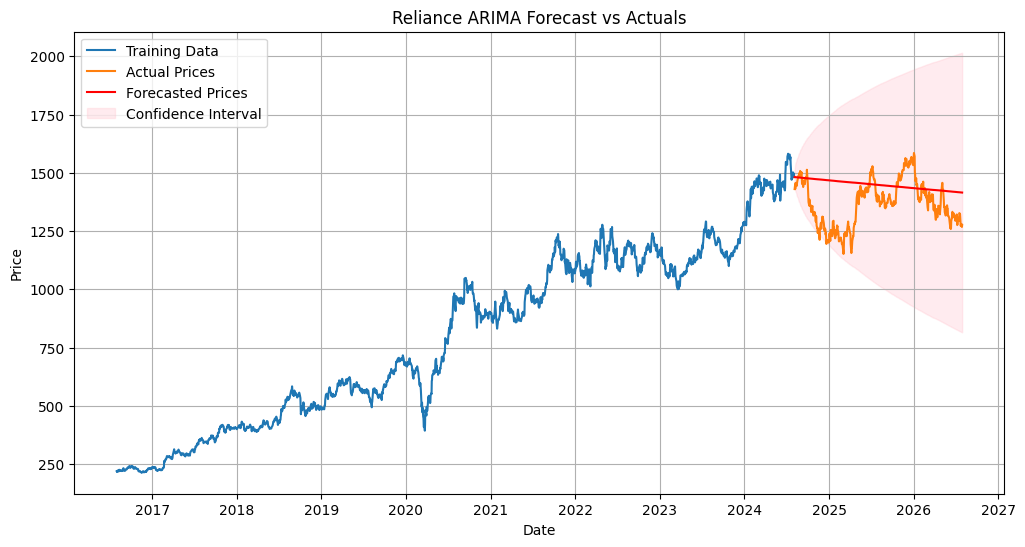

In [ ]:
reliance_arima_model, reliance_arima_rmse, reliance_arima_mae, reliance_arima_forecast = arima_model_pipeline(reliance_data_cleaned, 'Reliance')

**Reasoning**:
Adding more detailed debugging prints to the `arima_model_pipeline` function to inspect the `comparison_df` just before evaluation, checking its head, tail, and null counts. This will help identify if any non-finite values are present in the data passed to `mean_squared_error`.




Fitting ARIMA model for Reliance...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=16121.571, Time=1.37 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=32402.721, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=1.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=1.69 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=16120.780, Time=2.74 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.97 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=16123.322, Time=2.82 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=16123.409, Time=3.93 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=16122.179, Time=1.24 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=1.30 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=2.21 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=16121.403, Time=2.63 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 22.121 seconds
                               SARIMAX Results                      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


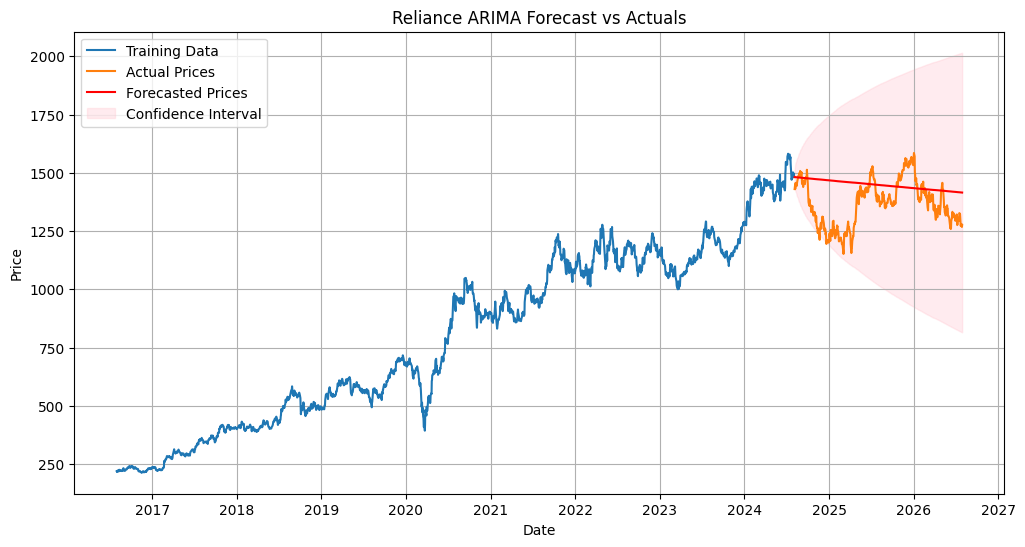

In [ ]:
def arima_model_pipeline(data_series, title_prefix):
    # Ensure data_series is a pandas Series
    if isinstance(data_series, pd.DataFrame):
        if len(data_series.columns) > 1:
            raise ValueError("Input data_series DataFrame has multiple columns. Expected a single column or a Series.")
        data_series = data_series.iloc[:, 0] # Convert single-column DataFrame to Series
    elif not isinstance(data_series, pd.Series):
        raise TypeError("Input data_series must be a pandas Series or a single-column DataFrame.")

    # 1. Split the data into training and testing sets
    train_size = int(len(data_series) * 0.8)
    train_data, test_data = data_series[0:train_size], data_series[train_size:]

    # 2. Identify appropriate ARIMA orders (p, d, q) using auto_arima
    print(f"\nFitting ARIMA model for {title_prefix}...")
    arima_model = pm.auto_arima(train_data,
                                start_p=1, start_q=1,
                                test='adf',       # use adftest to find optimal 'd'
                                max_p=5, max_q=5,  # maximum p and q
                                m=1,              # frequency of series
                                d=None,           # let model determine 'd'
                                seasonal=False,   # No Seasonality
                                start_P=0,
                                D=0,
                                trace=True,
                                error_action='ignore',
                                suppress_warnings=True,
                                stepwise=True)

    print(arima_model.summary())

    # 3. Make predictions
    raw_forecast, raw_conf_int = arima_model.predict(n_periods=len(test_data), return_conf_int=True)

    # If raw_forecast is a pandas Series or DataFrame, extract its values
    if isinstance(raw_forecast, (pd.Series, pd.DataFrame)):
        forecast_values = raw_forecast.values
    else: # Assume it's already a numpy array
        forecast_values = raw_forecast

    if isinstance(raw_conf_int, (pd.Series, pd.DataFrame)):
        conf_int_values = raw_conf_int.values
    else: # Assume it's already a numpy array
        conf_int_values = raw_conf_int

    print(f"Length of forecast_values: {len(forecast_values)}")
    print(f"First 5 values of forecast_values: {forecast_values[:5]}")
    print(f"Length of test_data Series: {len(test_data)}")
    print(f"First 5 indices of test_data: {test_data.index[:5]}")

    # Convert forecast_values and conf_int_values to pandas Series/DataFrame with test_data index
    # This should now correctly map the values if lengths match.
    forecast_series = pd.Series(forecast_values, index=test_data.index)
    conf_int_df = pd.DataFrame(conf_int_values, index=test_data.index, columns=['lower', 'upper'])

    # Explicitly handle infinite values by converting them to NaN
    test_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    forecast_series.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Debugging: Check for NaNs before evaluation
    print(f"NaNs in test_data before evaluation: {test_data.isnull().sum()}")
    print(f"NaNs in forecast_series before evaluation: {forecast_series.isnull().sum()}")

    # Align actual and forecasted values and drop any NaNs for robust evaluation
    comparison_df = pd.DataFrame({'Actual': test_data, 'Forecast': forecast_series})

    print("\n--- Debugging comparison_df before dropna ---")
    print(comparison_df.head())
    print(comparison_df.tail())
    print(f"NaNs in comparison_df before dropna: {comparison_df.isnull().sum().sum()}")
    print("------------------------------------------")

    comparison_df.dropna(inplace=True)

    print("\n--- Debugging comparison_df AFTER dropna ---")
    print(comparison_df.head())
    print(comparison_df.tail())
    print(f"NaNs in comparison_df AFTER dropna: {comparison_df.isnull().sum().sum()}")
    print("------------------------------------------")

    if comparison_df.empty:
        print("Warning: No common non-NaN values for evaluation. Skipping RMSE/MAE calculation.")
        rmse = np.nan
        mae = np.nan
    else:
        # 4. Evaluate the predictions
        rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['Forecast']))
        mae = mean_absolute_error(comparison_df['Actual'], comparison_df['Forecast'])

    print(f"\n{title_prefix} ARIMA Model Performance:")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")

    # 5. Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(train_data.index, train_data, label='Training Data')
    plt.plot(test_data.index, test_data, label='Actual Prices')
    plt.plot(forecast_series.index, forecast_series, label='Forecasted Prices', color='red')
    plt.fill_between(conf_int_df.index,
                     conf_int_df['lower'],
                     conf_int_df['upper'],
                     color='pink', alpha=0.3, label='Confidence Interval')
    plt.title(f'{title_prefix} ARIMA Forecast vs Actuals')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    return arima_model, rmse, mae, forecast_series

reliance_arima_model, reliance_arima_rmse, reliance_arima_mae, reliance_arima_forecast = arima_model_pipeline(reliance_data_cleaned, 'Reliance')

# Task
The user wants to perform a comprehensive stock market analysis and forecasting task for Nifty 50 and Reliance Industries using multiple modeling techniques. The task involves preparing data, engineering features, building various models (ARIMA, GARCH, LSTM/Transformer), comparing their performance, interpreting results with SHAP, and visualizing the findings. The goal is to predict stock prices and volatility, and gain insights into their behavior.

## Implement GARCH Model for Reliance Volatility

### Subtask:
Implement the GARCH(1,1) model for Reliance Industries volatility forecasting. This involves calculating daily returns, defining a GARCH pipeline, fitting the model, forecasting conditional volatility, and visualizing the results.


**Reasoning**:
Calculate the daily returns for the `reliance_data_cleaned` series.



In [ ]:
reliance_returns = reliance_data_cleaned.pct_change().dropna()
print("Reliance Daily Returns Head:")
display(reliance_returns.head())
print("\nReliance Daily Returns Info:")
reliance_returns.info()


Reliance Daily Returns Head:


Ticker,RELIANCE.NS
Date,
2016-08-02,0.003269
2016-08-03,-0.018612
2016-08-04,-0.000956
2016-08-05,0.023414
2016-08-08,0.012792



Reliance Daily Returns Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2470 entries, 2016-08-02 to 2026-07-29
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RELIANCE.NS  2470 non-null   float64
dtypes: float64(1)
memory usage: 38.6 KB


**Reasoning**:
Import the `arch` library for GARCH modeling.



In [ ]:
import sys
!{sys.executable} -m pip install arch

import arch

print("arch library imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.9 MB/s eta 0:00:00
arch library imported successfully.


**Reasoning**:
Define and fit the GARCH(1,1) model to the squared `reliance_returns` to forecast volatility.



In [ ]:
from arch import arch_model

# The reliance_returns is a DataFrame, we need to pass the Series for GARCH model
returns_series = reliance_returns['RELIANCE.NS']

# Define the GARCH(1,1) model with a constant mean (default)
model = arch_model(returns_series, vol='GARCH', p=1, q=1)

# Fit the model
res = model.fit(update_freq=10) # update_freq for verbose output during optimization

print(res.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: -6760.320805087511
            Iterations: 4
            Function evaluations: 52
            Gradient evaluations: 4
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            RELIANCE.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6760.32
Distribution:                  Normal   AIC:                          -13512.6
Method:            Maximum Likelihood   BIC:                          -13489.4
                                        No. Observations:                 2470
Date:                Wed, Jul 29 2026   Df Residuals:                     2469
Time:                        19:40:14   Df Model:                            1
                                 Mean Model                                 
    

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002905. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


**Reasoning**:
Forecast the conditional volatility using the fitted GARCH model and visualize the results to observe the predicted volatility over time.



Forecasted Conditional Volatility (next 5 days):


array([0.01386829, 0.01421793, 0.01452541, 0.01479668, 0.01503664])

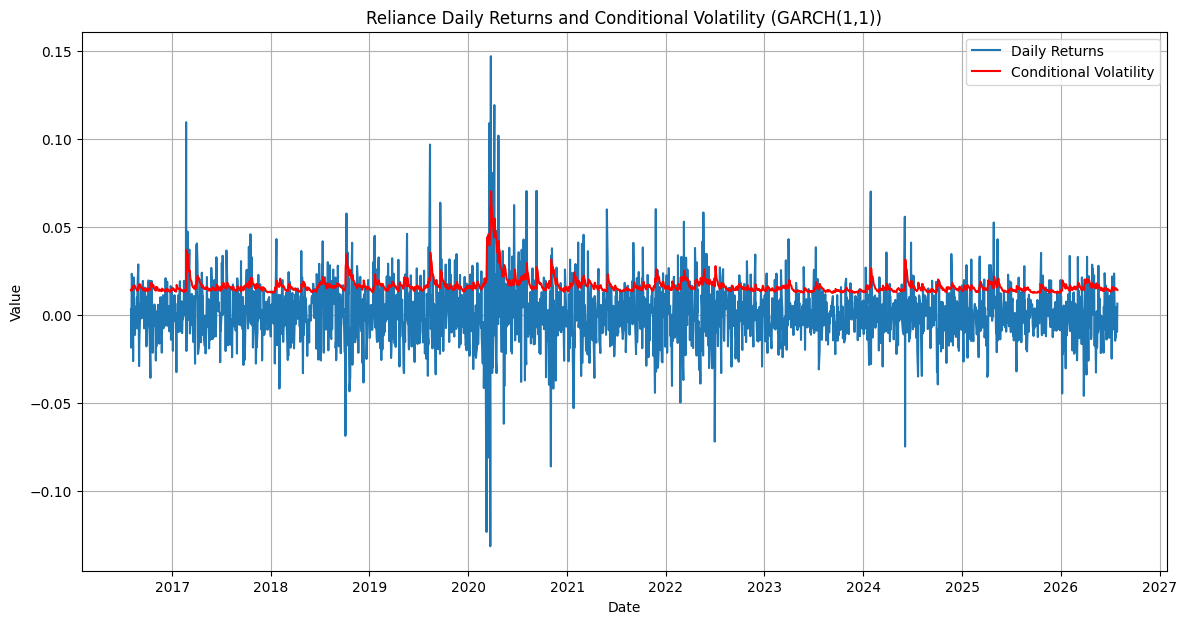

In [ ]:
forecasts = res.forecast(horizon=5)
conditional_volatility = np.sqrt(forecasts.variance.values[-1, :])

print("Forecasted Conditional Volatility (next 5 days):")
display(conditional_volatility)

# Plotting the conditional volatility
plt.figure(figsize=(14, 7))
plt.plot(returns_series.index, returns_series, label='Daily Returns')
plt.plot(res.conditional_volatility.index, res.conditional_volatility, label='Conditional Volatility', color='red')
plt.title('Reliance Daily Returns and Conditional Volatility (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Implement GARCH Model for Nifty 50 Volatility

### Subtask:
Implement the GARCH(1,1) model for Nifty 50 volatility forecasting, following the same methodology as for Reliance Industries. This will involve calculating daily returns, fitting the GARCH model, forecasting conditional volatility, and visualizing the results.


**Reasoning**:
Calculate the daily returns for the `nifty_data_cleaned` series, then display its head and info to verify the result, as per the instructions.



In [ ]:
nifty_returns = nifty_data_cleaned.pct_change().dropna()
print("Nifty Daily Returns Head:")
display(nifty_returns.head())
print("\nNifty Daily Returns Info:")
nifty_returns.info()

Nifty Daily Returns Head:


Ticker,^NSEI
Date,
2016-08-02,-0.001580
2016-08-03,-0.009052
2016-08-04,0.000731
2016-08-05,0.015443
2016-08-08,0.003248



Nifty Daily Returns Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2461 entries, 2016-08-02 to 2026-07-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^NSEI   2461 non-null   float64
dtypes: float64(1)
memory usage: 38.5 KB


**Reasoning**:
Define and fit the GARCH(1,1) model to the Nifty 50 daily returns, similar to the Reliance data, using the `arch_model` function.



In [ ]:
from arch import arch_model

# The nifty_returns is a DataFrame, we need to pass the Series for GARCH model
returns_series_nifty = nifty_returns['^NSEI']

# Define the GARCH(1,1) model with a constant mean (default)
model_nifty = arch_model(returns_series_nifty, vol='GARCH', p=1, q=1)

# Fit the model
res_nifty = model_nifty.fit(update_freq=10) # update_freq for verbose output during optimization

print(res_nifty.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: -8244.037302505005
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 5
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^NSEI   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                8244.04
Distribution:                  Normal   AIC:                          -16480.1
Method:            Maximum Likelihood   BIC:                          -16456.8
                                        No. Observations:                 2461
Date:                Wed, Jul 29 2026   Df Residuals:                     2460
Time:                        19:42:00   Df Model:                            1
                                 Mean Model                                 
    

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001046. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


**Reasoning**:
Forecast the conditional volatility using the fitted Nifty 50 GARCH model (`res_nifty`) and then visualize both the Nifty 50 daily returns and the forecasted conditional volatility.



Forecasted Nifty 50 Conditional Volatility (next 5 days):


array([0.00782219, 0.00787753, 0.00793139, 0.00798383, 0.00803488])

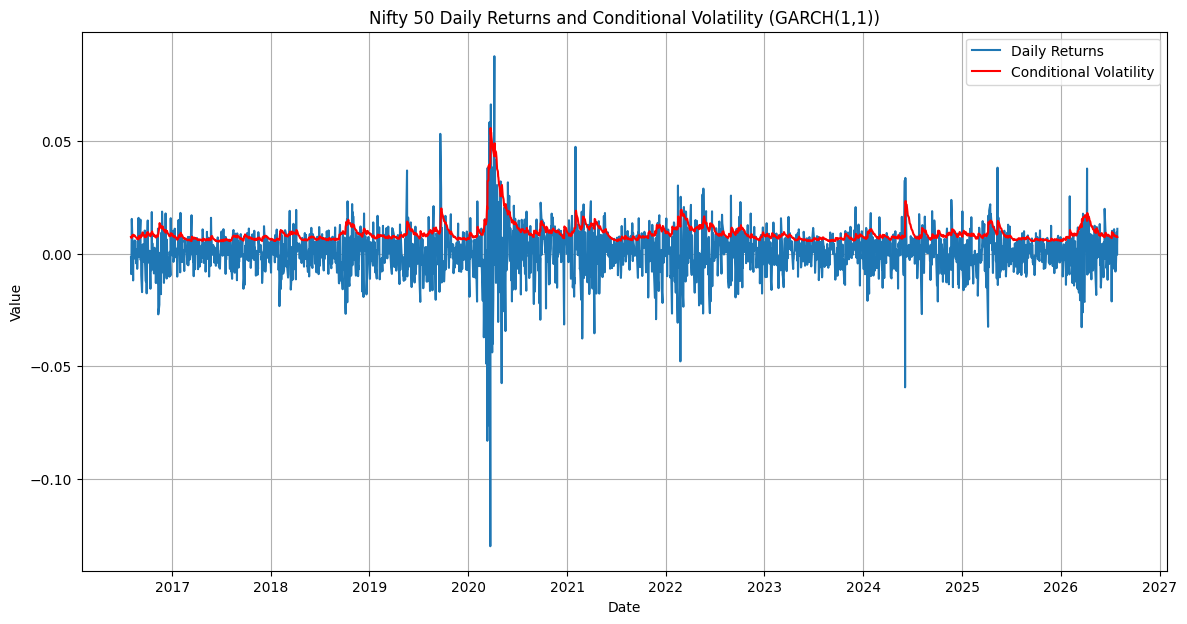

In [ ]:
forecasts_nifty = res_nifty.forecast(horizon=5)
conditional_volatility_nifty = np.sqrt(forecasts_nifty.variance.values[-1, :])

print("Forecasted Nifty 50 Conditional Volatility (next 5 days):")
display(conditional_volatility_nifty)

# Plotting the conditional volatility
plt.figure(figsize=(14, 7))
plt.plot(returns_series_nifty.index, returns_series_nifty, label='Daily Returns')
plt.plot(res_nifty.conditional_volatility.index, res_nifty.conditional_volatility, label='Conditional Volatility', color='red')
plt.title('Nifty 50 Daily Returns and Conditional Volatility (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Develop LSTM/Transformer Models

### Subtask:
Develop and train deep learning models (LSTM or Transformer) for stock price prediction for both Nifty 50 and Reliance Industries. This includes data preparation, model architecture definition, training, and initial evaluation.


**Reasoning**:
Prepare the Nifty 50 data for LSTM modeling by scaling the 'Nifty_Close' column, defining a function to create sequences, and then applying this function to generate training and testing sets for the LSTM model. This covers the first three instructions of the subtask.



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Extract the 'Nifty_Close' prices for scaling
nifty_close_prices = nifty_features_df['Nifty_Close'].values.reshape(-1, 1)

# Scale the data using MinMaxScaler
scaler_nifty = MinMaxScaler(feature_range=(0, 1))
scaled_nifty_data = scaler_nifty.fit_transform(nifty_close_prices)

# Define the number of time steps (look-back period)
time_step = 60

# Function to create sequences for LSTM
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Split data into training and testing sets (80% train, 20% test)
train_size_nifty = int(len(scaled_nifty_data) * 0.8)
train_data_nifty = scaled_nifty_data[0:train_size_nifty, :]
test_data_nifty = scaled_nifty_data[train_size_nifty:len(scaled_nifty_data), :]

# Create sequences for Nifty 50 training data
X_train_nifty, y_train_nifty = create_sequences(train_data_nifty, time_step)

# Create sequences for Nifty 50 testing data
X_test_nifty, y_test_nifty = create_sequences(test_data_nifty, time_step)

print("Nifty 50 Data Preparation for LSTM Completed:")
print(f"X_train_nifty shape: {X_train_nifty.shape}")
print(f"y_train_nifty shape: {y_train_nifty.shape}")
print(f"X_test_nifty shape: {X_test_nifty.shape}")
print(f"y_test_nifty shape: {y_test_nifty.shape}")

Nifty 50 Data Preparation for LSTM Completed:
X_train_nifty shape: (1892, 60)
y_train_nifty shape: (1892,)
X_test_nifty shape: (428, 60)
y_test_nifty shape: (428,)


**Reasoning**:
Prepare the Reliance data for LSTM modeling by scaling the 'Reliance_Close' column, defining a function to create sequences, and then applying this function to generate training and testing sets for the LSTM model. This covers the remaining data preparation part of the subtask for Reliance.



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Extract the 'Reliance_Close' prices for scaling
reliance_close_prices = reliance_features_df['Reliance_Close'].values.reshape(-1, 1)

# Scale the data using MinMaxScaler
scaler_reliance = MinMaxScaler(feature_range=(0, 1))
scaled_reliance_data = scaler_reliance.fit_transform(reliance_close_prices)

# Define the number of time steps (look-back period) - using the same as Nifty for consistency
time_step_reliance = 60

# Split data into training and testing sets (80% train, 20% test)
train_size_reliance = int(len(scaled_reliance_data) * 0.8)
train_data_reliance = scaled_reliance_data[0:train_size_reliance, :]
test_data_reliance = scaled_reliance_data[train_size_reliance:len(scaled_reliance_data), :]

# Create sequences for Reliance training data
X_train_reliance, y_train_reliance = create_sequences(train_data_reliance, time_step_reliance)

# Create sequences for Reliance testing data
X_test_reliance, y_test_reliance = create_sequences(test_data_reliance, time_step_reliance)

print("Reliance Data Preparation for LSTM Completed:")
print(f"X_train_reliance shape: {X_train_reliance.shape}")
print(f"y_train_reliance shape: {y_train_reliance.shape}")
print(f"X_test_reliance shape: {X_test_reliance.shape}")
print(f"y_test_reliance shape: {y_test_reliance.shape}")

Reliance Data Preparation for LSTM Completed:
X_train_reliance shape: (1899, 60)
y_train_reliance shape: (1899,)
X_test_reliance shape: (430, 60)
y_test_reliance shape: (430,)


**Reasoning**:
Define and build the LSTM model architecture for stock price prediction. This involves importing the necessary libraries from Keras (Sequential, LSTM, Dense) and then constructing the model with appropriate input shapes and layers.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape input to be [samples, time_steps, features] for LSTM
X_train_nifty_reshaped = X_train_nifty.reshape(X_train_nifty.shape[0], X_train_nifty.shape[1], 1)
X_test_nifty_reshaped = X_test_nifty.reshape(X_test_nifty.shape[0], X_test_nifty.shape[1], 1)

X_train_reliance_reshaped = X_train_reliance.reshape(X_train_reliance.shape[0], X_train_reliance.shape[1], 1)
X_test_reliance_reshaped = X_test_reliance.reshape(X_test_reliance.shape[0], X_test_reliance.shape[1], 1)

# Define the LSTM model architecture
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build the Nifty 50 LSTM model
nifty_lstm_model = create_lstm_model((time_step, 1))
print("Nifty 50 LSTM Model Summary:")
nifty_lstm_model.summary()

# Build the Reliance LSTM model
reliance_lstm_model = create_lstm_model((time_step_reliance, 1))
print("\nReliance LSTM Model Summary:")
reliance_lstm_model.summary()

Nifty 50 LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

\**Reasoning**:
Train the defined LSTM models for both Nifty 50 and Reliance data using the prepared training sets (X_train_nifty_reshaped, y_train_nifty, X_train_reliance_reshaped, y_train_reliance) for a specified number of epochs and batch size. This covers the 'training' part of the subtask.



In [ ]:
epochs = 20
batch_size = 64

# Train Nifty 50 LSTM model
print("\nTraining Nifty 50 LSTM Model...")
history_nifty = nifty_lstm_model.fit(X_train_nifty_reshaped, y_train_nifty, epochs=epochs, batch_size=batch_size, verbose=1)
print("Nifty 50 LSTM Model training complete.")

# Train Reliance LSTM model
print("\nTraining Reliance LSTM Model...")
history_reliance = reliance_lstm_model.fit(X_train_reliance_reshaped, y_train_reliance, epochs=epochs, batch_size=batch_size, verbose=1)
print("Reliance LSTM Model training complete.")


Training Nifty 50 LSTM Model...
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0321
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0012
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 3.6492e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 3.1737e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 3.0797e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 3.0132e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 2.9941e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 2.9393e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.8972e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 3.0142e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.8994e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 2.7726e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 2.7694e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 

**Reasoning**:
Evaluate the trained LSTM models for Nifty 50 and Reliance by making predictions on the test sets, inverse transforming the predictions and actual values, calculating evaluation metrics (RMSE, MAE), and visualizing the results. This covers the 'initial evaluation' part of the subtask.




Evaluating Nifty 50 LSTM Model...
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Nifty 50 LSTM RMSE: 484.187
Nifty 50 LSTM MAE: 386.563


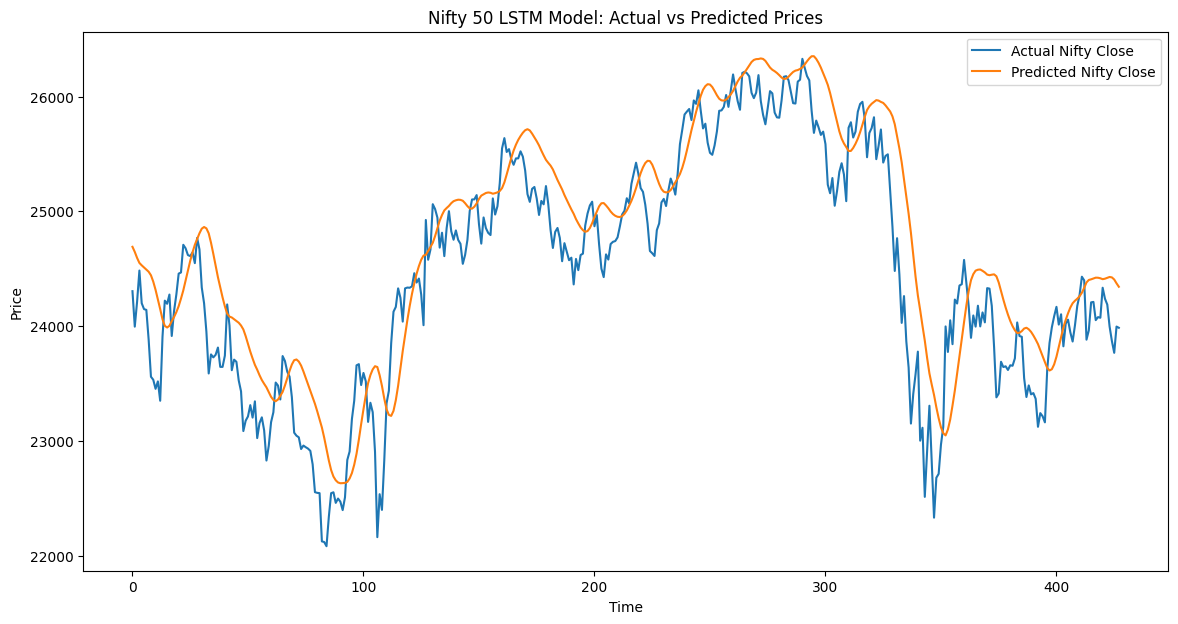


Evaluating Reliance LSTM Model...
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Reliance LSTM RMSE: 38.852
Reliance LSTM MAE: 30.738


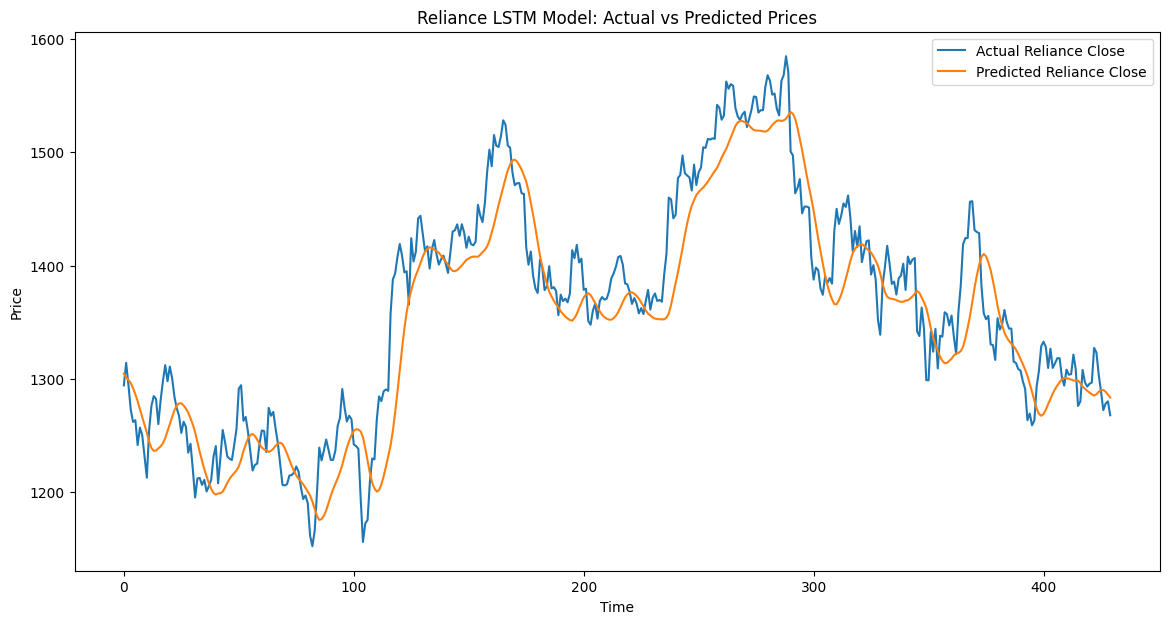

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# --- Nifty 50 LSTM Model Evaluation ---
print("\nEvaluating Nifty 50 LSTM Model...")
# Make predictions
nifty_test_predict = nifty_lstm_model.predict(X_test_nifty_reshaped)

# Inverse transform predictions and actual values
nifty_test_predict = scaler_nifty.inverse_transform(nifty_test_predict)
y_test_nifty_inversed = scaler_nifty.inverse_transform(y_test_nifty.reshape(-1, 1))

# Calculate RMSE and MAE
nifty_lstm_rmse = np.sqrt(mean_squared_error(y_test_nifty_inversed, nifty_test_predict))
nifty_lstm_mae = mean_absolute_error(y_test_nifty_inversed, nifty_test_predict)

print(f"Nifty 50 LSTM RMSE: {nifty_lstm_rmse:.3f}")
print(f"Nifty 50 LSTM MAE: {nifty_lstm_mae:.3f}")

# Plotting Nifty 50 predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test_nifty_inversed, label='Actual Nifty Close')
plt.plot(nifty_test_predict, label='Predicted Nifty Close')
plt.title('Nifty 50 LSTM Model: Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# --- Reliance LSTM Model Evaluation ---
print("\nEvaluating Reliance LSTM Model...")
# Make predictions
reliance_test_predict = reliance_lstm_model.predict(X_test_reliance_reshaped)

# Inverse transform predictions and actual values
reliance_test_predict = scaler_reliance.inverse_transform(reliance_test_predict)
y_test_reliance_inversed = scaler_reliance.inverse_transform(y_test_reliance.reshape(-1, 1))

# Calculate RMSE and MAE
reliance_lstm_rmse = np.sqrt(mean_squared_error(y_test_reliance_inversed, reliance_test_predict))
reliance_lstm_mae = mean_absolute_error(y_test_reliance_inversed, reliance_test_predict)

print(f"Reliance LSTM RMSE: {reliance_lstm_rmse:.3f}")
print(f"Reliance LSTM MAE: {reliance_lstm_mae:.3f}")

# Plotting Reliance predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test_reliance_inversed, label='Actual Reliance Close')
plt.plot(reliance_test_predict, label='Predicted Reliance Close')
plt.title('Reliance LSTM Model: Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()